# Gradient Descent — Batch, Stochastic, and Mini-Batch

## Goal

This notebook derives gradient descent as a general iterative optimization
method, then implements and compares three variants — batch, stochastic,
and mini-batch — which differ only in how many data points are used to
estimate the gradient at each update step.

All three share the same gradient and the same update rule. The goal is to
show that explicitly, rather than treating them as separate algorithms.

## Setup

Recall from the multivariable regression notebook:

$$ \hat{y}_i = B_0 + B_1x_{i1} + B_2x_{i2} + \dots + B_px_{ip} $$

$$ E = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

(Here we use **Mean** Squared Error, scaled by $\frac{1}{n}$ — a different
convention from the Normal Equation notebook, which used plain $\sum$.
Either works; the $\frac{1}{n}$ and the constant $-2$ both get absorbed
into the choice of learning rate in practice.)

## What Does $\frac{\partial E}{\partial B_j}$ Actually Tell Us?

$\frac{\partial E}{\partial B_j}$ is **not** "the portion of error caused
by $B_j$" — error is one number describing the total wrongness of the
model; it doesn't split into per-parameter pieces.

$\frac{\partial E}{\partial B_j}$ is a **sensitivity**: it tells us how
much the *total* error would change if we nudged $B_j$ slightly, holding
every other parameter fixed — both the **direction** of that change (the
sign) and **how fast** (the magnitude). It is a rate of change, not a
quantity of error.

**Why does the sign tell us which way to move $B_j$?**
- If $\frac{\partial E}{\partial B_j} > 0$: increasing $B_j$ increases
  error → move $B_j$ down to reduce error.
- If $\frac{\partial E}{\partial B_j} < 0$: increasing $B_j$ decreases
  error → move $B_j$ up to reduce error.

In both cases, **subtracting** the gradient produces the correct
direction — this is exactly why the update rule uses subtraction, not
addition.

## Deriving $\frac{\partial E}{\partial B_j}$ for Each Parameter

$$ \frac{\partial E}{\partial B_0} = \frac{-2}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i) $$

$$ \frac{\partial E}{\partial B_1} = \frac{-2}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)x_{i1} $$

$$ \frac{\partial E}{\partial B_2} = \frac{-2}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)x_{i2} $$

$$ \vdots $$

$$ \frac{\partial E}{\partial B_p} = \frac{-2}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)x_{ip} $$

The pattern is identical for every $B_j$ — only the feature column
$x_{ij}$ changes ($B_0$'s "feature" is implicitly $1$ for every row,
which is why no $x$ term appears there).

## The Update Rule

$$ B_j := B_j - \alpha \frac{\partial E}{\partial B_j} \quad \text{for every } j $$

**Why subtract, specifically?** Subtracting the gradient always moves
$B_j$ opposite to the direction that increases error — exactly the
direction that decreases it, as shown above.

**Why a separate learning rate $\alpha$, instead of using the gradient
directly?** The gradient only tells us a *direction* and *local steepness*
— not how large a step to take. Too large a step risks overshooting past
the minimum (divergence); too small wastes time converging. $\alpha$ is a
deliberately chosen scale factor, not something calculus provides
automatically.

**Why does repeating this reduce error over time?** At any point where the
gradient isn't exactly zero, the slope accurately describes which
direction is downhill *right at that point*. A small enough step in that
direction genuinely reduces $E$. Repeating this many times walks the
parameters down into the bowl-shaped error surface, until the gradient is
close to zero and further steps barely move anything.

*(Note: this guarantees a step-by-step decrease for a small enough $\alpha$,
and convergence to the true minimum for a convex loss like ours — sum of
squared errors. For more complex, non-convex loss surfaces, the same logic
only guarantees reaching some low point, not necessarily the lowest one
overall.)*

**Why divide by $n$ here, when the Normal Equation notebook didn't?**

Two ways to write essentially the same loss:

- **Sum of Squared Error (SSE):** $E = \sum_{i=1}^{n}(y_i-\hat y_i)^2$
- **Mean Squared Error (MSE):** $E = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2$

Dividing by $n$ just rescales the gradient by a constant factor. For
example, with $n=100$, a gradient that comes out to $-2000$ under SSE
becomes $-20$ under MSE — 100x smaller, purely from the division, with
nothing else different.

This doesn't change what the algorithm converges to, because the update
rule is $B_j := B_j - \alpha \times \text{gradient}$ — a smaller gradient
can always be compensated with a correspondingly larger $\alpha$, producing
the exact same step size either way. SSE and MSE are the same algorithm
wearing different clothes.

The real reason MSE is preferred: with SSE, the loss value grows simply
because a dataset has more rows — 1000 rows naturally produces a bigger
sum-of-squares than 100 rows, even with an equally good model. That makes
it awkward to compare loss values across different dataset sizes, or to
pick one default learning rate that works reasonably well regardless of
how much data you have. MSE divides that out, so the loss reflects
"average error per point" — a value that stays roughly the same scale no
matter how much data you have. It's a bookkeeping convenience, not a
mathematical necessity.

## Why Compare Every Variant Against scikit-learn's `LinearRegression`?

`LinearRegression` solves this same problem — minimizing the sum of
squared errors — using the Normal Equation, a closed-form calculation
with no approximation or iteration involved. Because the loss surface for
linear regression is convex (a single bowl shape, as shown in the
Normal Equation notebook), there is exactly **one correct answer** to
this minimization problem, and `LinearRegression` computes it directly.

That makes it the right ground truth for checking whether each gradient
descent variant — which finds this same answer by walking downhill
iteratively, rather than solving algebraically — actually arrives at the
correct result, or gets stuck, stops early, or diverges instead.

Each variant is expected to compare differently against this ground
truth, for a specific, predictable reason tied to how it estimates the
gradient at each step:

- **Batch GD** uses the true, full-dataset gradient at every step, so
  given enough epochs, it should converge **exactly** to the closed-form
  answer.
- **Stochastic GD** estimates the gradient from a single random row each
  step — a noisy approximation of the true gradient. It converges
  **close to, but not exactly**, the closed-form answer, and continues to
  jitter around it rather than settling.
- **Mini-batch GD** estimates the gradient from a small random subset
  each step, averaging out some of that noise — so it should land
  **somewhere between** batch's exactness and stochastic's jitter.

Comparing each variant against the same fixed ground truth, rather than
against each other, makes these differences directly visible and lets us
confirm that each implementation behaves the way the underlying math
predicts it should.

## Why Use Gradient Descent at All, When `LinearRegression` Already Gives the Exact Answer?

For plain linear regression specifically, you genuinely don't need
gradient descent — the Normal Equation is faster, exact, and simpler.
This raises a fair question: why build it here at all?

**Gradient descent is a fairly complex technique, and linear regression
is the easiest place to learn it correctly** — because it's the one
problem where the loss surface is simple enough (a convex bowl) and a
known, exact, independently-derived answer already exists to check
against. That makes it possible to *prove* gradient descent is working
correctly, step by step, rather than just hoping it is.

**The real reason gradient descent matters goes beyond linear
regression.** The Normal Equation only exists because of a specific
mathematical coincidence: squared-error loss combined with a linear model
produces a quadratic loss function, and setting its gradient to zero gives
a *linear* system of equations — solvable directly by matrix inversion.
This does not hold for almost any other model:

- **Logistic regression** — the sigmoid function makes
  the gradient-equals-zero equation have no algebraic closed-form
  solution.
- **Neural networks** — stacked nonlinear layers make a closed-form
  solution essentially impossible to write down, regardless of dataset
  size.
- **Most of deep learning** — nearly every model trained in practice
  relies on gradient descent (or a variant of it, like Adam), because no
  algebraic shortcut exists.

So gradient descent isn't a *better* way to solve linear regression — the
Normal Equation already does that. Its real value is as a **general-
purpose optimization method** that keeps working even when no closed-form
solution exists, which is the case for nearly everything beyond linear
regression. Learning it here, where the correct answer is already known,
is what makes it possible to trust the method once there's no longer a
ground truth to check it against.

## Batch Gradient Regressor

In [1]:
class GradientDescentRegressor():
    def __init__ (self,learning_rate=0.01,epoches=50):
        self.learning_rate=learning_rate
        self.epoches=epoches
        self.intercept_=None
        self.coef_=None
        self.loss_history=[]

    def fit(self,x_train,y_train):
        self.intercept_=0
        self.coef_=np.zeros(x_train.shape[1])
        for i in range(self.epoches):
            y_hat=self.intercept_+np.dot(x_train,self.coef_)
            intercept_der=-2*np.mean(y_train-y_hat)
            self.intercept_=self.intercept_ - (self.learning_rate * intercept_der)
            coef_der=-2*(np.dot((y_train-y_hat),x_train))/x_train.shape[0]
            self.coef_=self.coef_ -(self.learning_rate * coef_der)
            y_hat=self.intercept_+np.dot(x_train,self.coef_)
            loss=np.mean((y_train-y_hat)**2)
            self.loss_history.append(loss)

    def predict(self,x_test):
        y_pred=self.intercept_ + np.dot(x_test,self.coef_)
        return y_pred


In [2]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
X, y = make_regression(
    n_samples=300,
    n_features=3,
    n_informative=3,
    noise=20,
    random_state=42
)
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [3]:
import numpy as np
my_gd=GradientDescentRegressor(learning_rate=0.1,epoches=1000)
my_gd.fit(x_train,y_train)
my_preds=my_gd.predict(x_test)
from sklearn.linear_model import LinearRegression

sk_lr = LinearRegression()
sk_lr.fit(x_train, y_train)

print("Batch GD (from scratch):")
print(f"  intercept_: {my_gd.intercept_:.4f}")
print(f"  coef_:      {my_gd.coef_}")

print("\nscikit-learn LinearRegression (closed-form, ground truth):")
print(f"  intercept_: {sk_lr.intercept_:.4f}")
print(f"  coef_:      {sk_lr.coef_}")

print(f"\nMax coef difference vs closed-form: {np.max(np.abs(my_gd.coef_ - sk_lr.coef_)):.4f}")
print(f"Intercept difference vs closed-form:  {abs(my_gd.intercept_ - sk_lr.intercept_):.4f}")

Batch GD (from scratch):
  intercept_: 0.7215
  coef_:      [82.93838036 81.38232408 16.47221654]

scikit-learn LinearRegression (closed-form, ground truth):
  intercept_: 0.7215
  coef_:      [82.93838036 81.38232408 16.47221654]

Max coef difference vs closed-form: 0.0000
Intercept difference vs closed-form:  0.0000


In [4]:
class StochasticGradientDescentRegressor():
    def __init__ (self,learning_rate=0.01,epoches=50):
        self.learning_rate=learning_rate
        self.epoches=epoches
        self.intercept_=None
        self.coef_=None
        self.loss_history=[]

    def fit(self,x_train,y_train):
        self.intercept_=0
        self.coef_=np.zeros(x_train.shape[1])
        for i in range(self.epoches):
            for j in range (x_train.shape[0]):
                idx=np.random.randint(0,x_train.shape[0])
                y_hat=self.intercept_+(np.dot(x_train[idx],self.coef_))
                intercept_der=-2*(y_train[idx]-y_hat)
                self.intercept_=self.intercept_ - (self.learning_rate*intercept_der)
                coef_der=-2*(np.dot((y_train[idx]-y_hat),x_train[idx]))
                self.coef_=self.coef_ - (self.learning_rate*coef_der)
        
        y_hat_full = self.intercept_ + np.dot(x_train, self.coef_)
        loss = np.mean((y_train - y_hat_full) ** 2)
        self.loss_history.append(loss)

    def predict(self,x_test):
        y_pred=self.intercept_ + np.dot(x_test,self.coef_)
        return y_pred
        

In [5]:
my_sgd=StochasticGradientDescentRegressor(learning_rate=0.001,epoches=1000)
my_sgd.fit(x_train,y_train)
my_sgd_pred=my_sgd.predict(x_test)

print("Stochastic GD (from scratch):")
print(f"  intercept_: {my_sgd.intercept_:.4f}")
print(f"  coef_:      {my_sgd.coef_}")


print("\nscikit-learn LinearRegression (closed-form, ground truth):")
print(f"  intercept_: {sk_lr.intercept_:.4f}")
print(f"  coef_:      {sk_lr.coef_}")

print(f"\nMax coef difference vs closed-form: {np.max(np.abs(my_sgd.coef_ - sk_lr.coef_)):.4f}")
print(f"Intercept difference vs closed-form:  {abs(my_sgd.intercept_ - sk_lr.intercept_):.4f}")

Stochastic GD (from scratch):
  intercept_: -0.3103
  coef_:      [83.37408125 80.68810792 15.68122274]

scikit-learn LinearRegression (closed-form, ground truth):
  intercept_: 0.7215
  coef_:      [82.93838036 81.38232408 16.47221654]

Max coef difference vs closed-form: 0.7910
Intercept difference vs closed-form:  1.0318


In [6]:
class MiniBatchGradientDescentRegressor():
    def __init__ (self,learning_rate=0.01,epoches=50,batch_size=50):
        self.learning_rate=learning_rate
        self.epoches=epoches
        self.batch_size=batch_size
        self.intercept_=None
        self.coef_=None
        self.loss_history=[]

    def fit(self,x_train,y_train):
        self.intercept_=0
        self.coef_=np.zeros(x_train.shape[1])
        for i in range(self.epoches):
            for j in range (int(x_train.shape[0]/self.batch_size)):
                idx=np.random.choice(x_train.shape[0],size=self.batch_size,replace=False)
                y_hat=self.intercept_+(np.dot(x_train[idx],self.coef_))
                intercept_der=-2*np.mean(y_train[idx]-y_hat)
                self.intercept_=self.intercept_ - (self.learning_rate*intercept_der)
                coef_der=-2*(np.dot((y_train[idx]-y_hat),x_train[idx]))/self.batch_size
                self.coef_=self.coef_ - (self.learning_rate*coef_der)
        
            y_hat_full = self.intercept_ + np.dot(x_train, self.coef_)
            loss = np.mean((y_train - y_hat_full) ** 2)
            self.loss_history.append(loss)

    def predict(self,x_test):
        y_pred=self.intercept_ + np.dot(x_test,self.coef_)
        return y_pred
        

In [7]:
my_mbgd=MiniBatchGradientDescentRegressor(learning_rate=0.001,epoches=1000,batch_size=50)
my_mbgd.fit(x_train,y_train)
mb_pred=my_mbgd.predict(x_test)

print("MiniBatch GD (from scratch):")
print(f"  intercept_: {my_mbgd.intercept_:.4f}")
print(f"  coef_:      {my_mbgd.coef_}")


print("\nscikit-learn LinearRegression (closed-form, ground truth):")
print(f"  intercept_: {sk_lr.intercept_:.4f}")
print(f"  coef_:      {sk_lr.coef_}")

print(f"\nMax coef difference vs closed-form: {np.max(np.abs(my_mbgd.coef_ - sk_lr.coef_)):.4f}")
print(f"Intercept difference vs closed-form:  {abs(my_mbgd.intercept_ - sk_lr.intercept_):.4f}")

MiniBatch GD (from scratch):
  intercept_: 0.6828
  coef_:      [82.94694579 81.43639066 16.36270412]

scikit-learn LinearRegression (closed-form, ground truth):
  intercept_: 0.7215
  coef_:      [82.93838036 81.38232408 16.47221654]

Max coef difference vs closed-form: 0.1095
Intercept difference vs closed-form:  0.0386


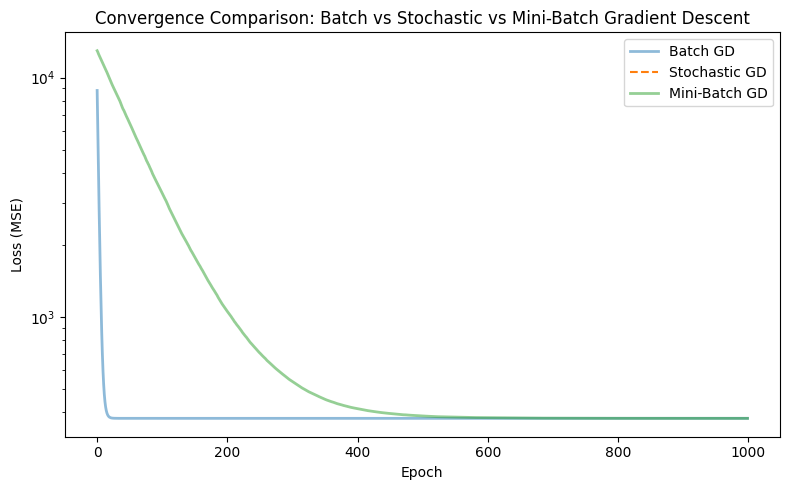

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(my_gd.loss_history, label="Batch GD",alpha=0.5, linewidth=2)
plt.plot(my_sgd.loss_history, label="Stochastic GD",linestyle="--")
plt.plot(my_mbgd.loss_history, label="Mini-Batch GD",alpha=0.5, linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Convergence Comparison: Batch vs Stochastic vs Mini-Batch Gradient Descent")
plt.legend()
plt.yscale("log") 
plt.tight_layout()
plt.show()

In [ ]:
!git add 